# **Facial Emotion Detection**

## **Problem Definition**

**The context:** Why is this problem important to solve?<br>
**The objectives:** What is the intended goal?<br>
**The key questions:** What are the key questions that need to be answered?<br>
**The problem formulation:** What are we trying to solve using data science?



## **About the dataset**

The data set consists of 3 folders, i.e., 'test', 'train', and 'validation'.
Each of these folders has four subfolders:

**‘happy’**: Images of people who have happy facial expressions.<br>
**‘sad’**: Images of people with sad or upset facial expressions.<br>
**‘surprise’**: Images of people who have shocked or surprised facial expressions.<br>
**‘neutral’**: Images of people showing no prominent emotion in their facial expression at all.<br>


## **Important Notes**

- This notebook can be considered a guide to refer to while solving the problem. The evaluation will be as per the Rubric shared for each Milestone. Unlike previous courses, it does not follow the pattern of the graded questions in different sections. This notebook would give you a direction on what steps need to be taken to get a feasible solution to the problem. Please note that this is just one way of doing this. **There can be other 'creative' ways to solve the problem, and we encourage you to feel free and explore them as an 'optional' exercise**.

- In the notebook, there are markdown cells called Observations and Insights. It is a good practice to provide observations and extract insights from the outputs.

- The naming convention for different variables can vary. **Please consider the code provided in this notebook as a sample code.**

- All the outputs in the notebook are just for reference and can be different if you follow a different approach.

- There are sections called **Think About It** in the notebook that will help you get a better understanding of the reasoning behind a particular technique/step. Interested learners can take alternative approaches if they want to explore different techniques.

## **Mounting the Drive**

**NOTE:**  Please use Google Colab from your browser for this notebook. **Google.colab is NOT a library that can be downloaded locally on your device.**

In [ ]:
# Mounting the drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **Importing the Libraries**

In [ ]:
import zipfile
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os

# Importing Deep Learning Libraries

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Input, Dropout, GlobalAveragePooling2D, Flatten, Conv2D, BatchNormalization, Activation, MaxPooling2D, LeakyReLU
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

### **Let us load the data**

**Note:**
- You must download the dataset from the link provided on Olympus and upload the same on your Google drive before executing the code in the next cell.
- In case of any error, please make sure that the path of the file is correct as the path may be different for you.

In [1]:
import os
import zipfile

# Storing the path of the data file from the Google drive
path = '/content/drive/MyDrive/AI Data Science MIT+/Capstone Project/Facial Emotion Detection/Facial_emotion_images.zip'

print(f"Checking for file at: {path}")




Checking for file at: /content/drive/MyDrive/AI Data Science MIT+/Capstone Project/Facial Emotion Detection/Facial_emotion_images.zip


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
picture_size = 48
folder_path = "Facial_emotion_images/"

## **Visualizing our Classes**

Let's look at our classes.

**Write down your observation for each class. What do you think can be a unique feature of each emotion, that separates it from the remaining classes?**

### **Happy**

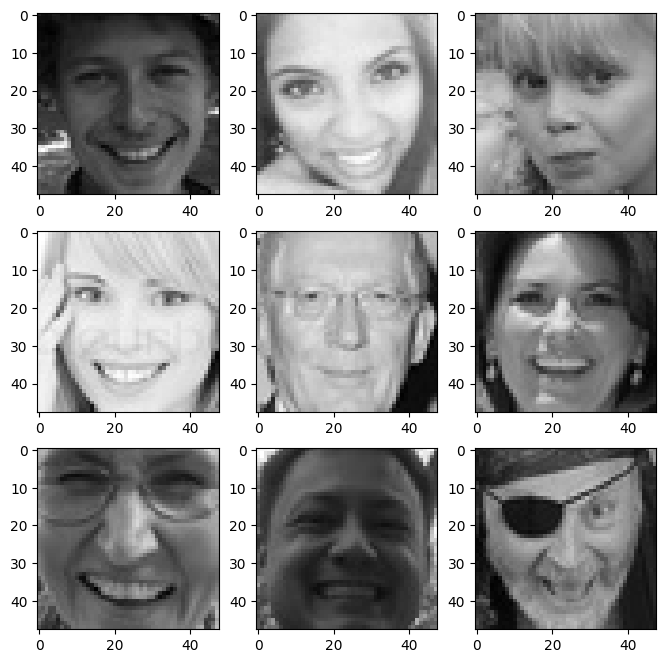

In [ ]:
expression = 'happy'

plt.figure(figsize= (8,8))
for i in range(1, 10, 1):
    plt.subplot(3, 3, i)

    img = load_img(folder_path + "train/" + expression + "/" +
                  os.listdir(folder_path + "train/" + expression)[i], target_size = (picture_size, picture_size))
    plt.imshow(img)

plt.show()

**Observations and Insights:__**

### **Sad**

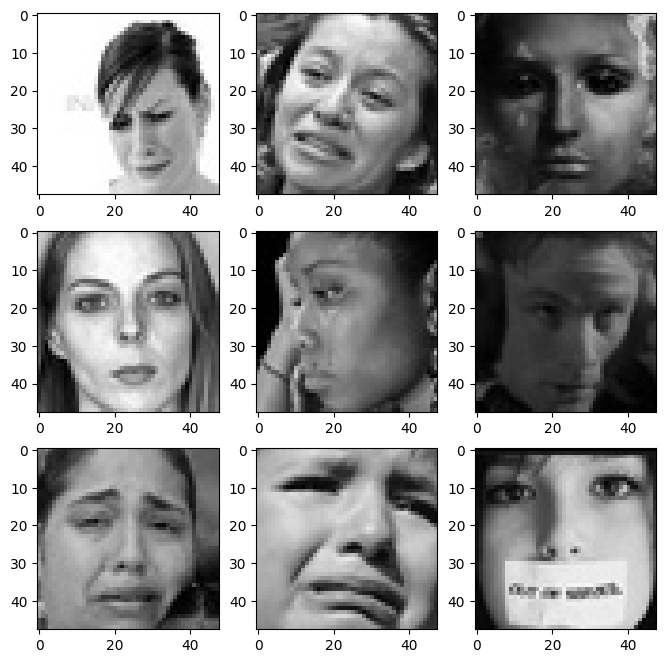

In [ ]:
# Write your code to visualize images from the class 'sad'.

expression = 'sad'

plt.figure(figsize= (8,8))
for i in range(1, 10, 1):
    plt.subplot(3, 3, i)

    img = load_img(folder_path + "train/" + expression + "/" +
                  os.listdir(folder_path + "train/" + expression)[i], target_size = (picture_size, picture_size))
    plt.imshow(img)

plt.show()

**Observations and Insights:__**

### **Neutral**

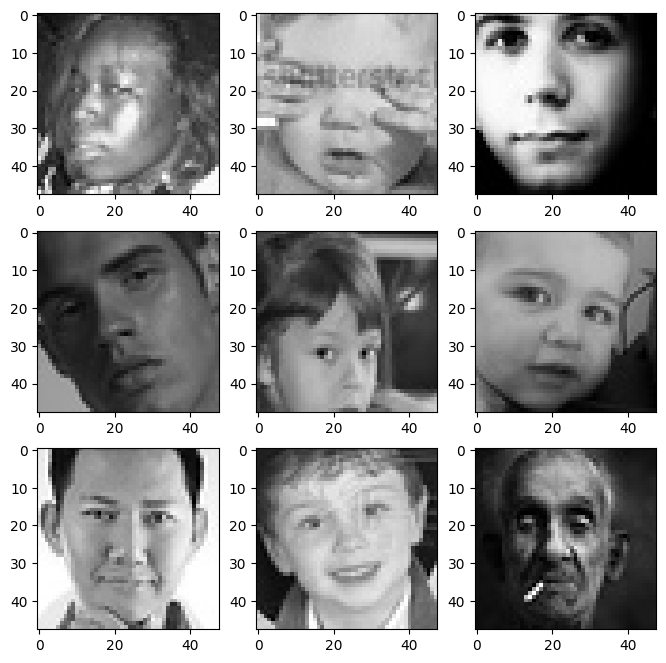

In [ ]:
# Write your code to visualize images from the class 'neutral'.

expression = 'neutral'

plt.figure(figsize= (8,8))
for i in range(1, 10, 1):
    plt.subplot(3, 3, i)

    img = load_img(folder_path + "train/" + expression + "/" +
                  os.listdir(folder_path + "train/" + expression)[i], target_size = (picture_size, picture_size))
    plt.imshow(img)

plt.show()

**Observations and Insights:__**

### **Surprised**

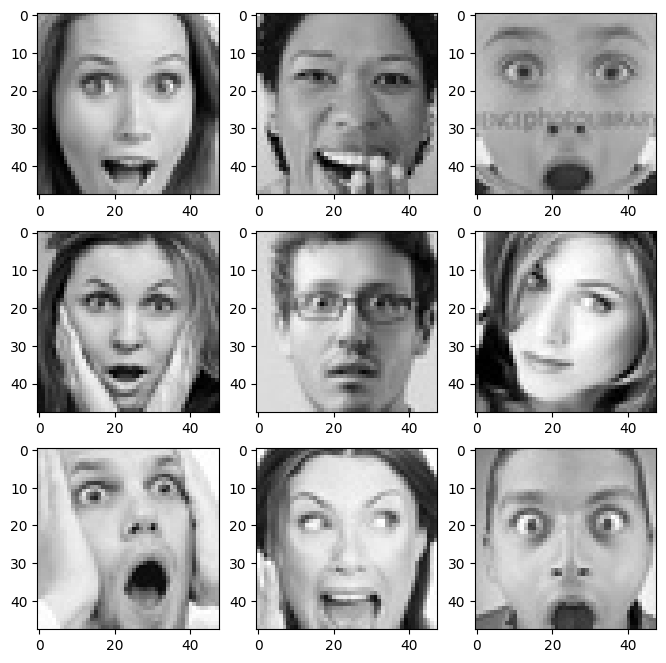

In [ ]:
# Write your code to visualize images from the class 'surprise'.

expression = 'surprise'

plt.figure(figsize= (8,8))
for i in range(1, 10, 1):
    plt.subplot(3, 3, i)

    img = load_img(folder_path + "train/" + expression + "/" +
                  os.listdir(folder_path + "train/" + expression)[i], target_size = (picture_size, picture_size))
    plt.imshow(img)

plt.show()

**Observations and Insights:__**

## **Checking Distribution of Classes**

In [ ]:
# Getting count of images in each folder within our training path
num_happy = len(os.listdir(folder_path + "train/happy"))
print("Number of images in the class 'happy':   ", num_happy)

#num_sad = # Write the code to get the number of training images from the class 'sad'.
num_sad = len(os.listdir(folder_path + "train/sad"))
print("Number of images in the class 'sad':   ", num_sad)

#num_neutral = # Write the code to get the number of training images from the class 'neutral'.
num_neutral = len(os.listdir(folder_path + "train/neutral"))
print("Number of images in the class 'neutral':   ", num_neutral)

#num_surprise = # Write the code to get the number of training images from the class 'surprise'.
num_surprise = len(os.listdir(folder_path + "train/surprise"))
print("Number of images in the class 'surprise':   ", num_surprise)

Number of images in the class 'happy':    3976
Number of images in the class 'sad':    3982
Number of images in the class 'neutral':    3978
Number of images in the class 'surprise':    3173


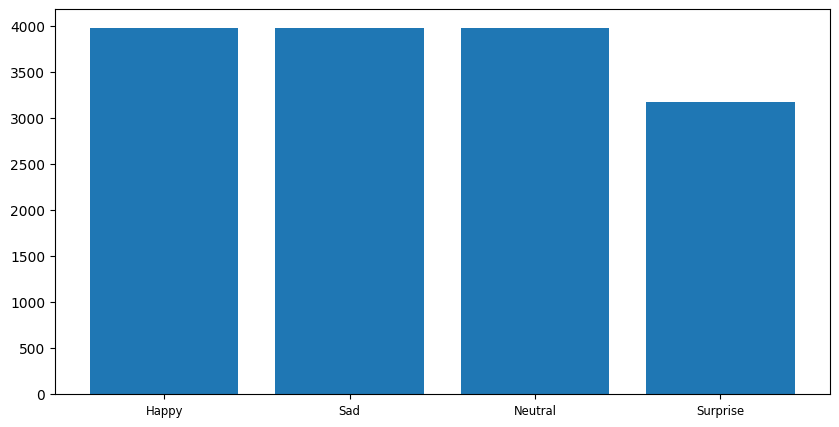

In [ ]:
# Code to plot histogram
plt.figure(figsize = (10, 5))

data = {'Happy': num_happy, 'Sad': num_sad, 'Neutral': num_neutral, 'Surprise' : num_surprise}

df = pd.Series(data)

plt.bar(range(len(df)), df.values, align = 'center')

plt.xticks(range(len(df)), df.index.values, size = 'small')

plt.show()

**Observations and Insights:__**

**Think About It:**
* Are the classes equally distributed? If not, do you think the imbalance is too high? Will it be a problem as we progress?
* Are there any Exploratory Data Analysis tasks that we can do here? Would they provide any meaningful insights?

## **Creating our Data Loaders**

In this section, we are creating data loaders that we will use as inputs to our Neural Network. A sample of the required code has been given with respect to the training data. Please create the data loaders for validation and test set accordingly.

**You have two options for the color_mode. You can set it to color_mode = 'rgb' or color_mode = 'grayscale'. You will need to try out both and see for yourself which one gives better performance.**

In [ ]:
batch_size  = 32
img_size = 48

datagen_train = ImageDataGenerator(horizontal_flip = True,
                                    brightness_range=(0.,2.),
                                    rescale=1./255,
                                    shear_range=0.3)

train_set = datagen_train.flow_from_directory(folder_path + "train",
                                              target_size = (img_size, img_size),
                                              color_mode = # Provide your chosen color_mode here ,
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              shuffle = True)


datagen_validation = # Write your code here

validation_set = # Write your code here


datagen_test = # Write your code here

test_set = # Write your code here

In [ ]:
batch_size  = 32
img_size = 48

# Training Generator with Data Augmentation
datagen_train = ImageDataGenerator(horizontal_flip = True,
                                    #brightness_range=(0.,2.), # Removed this line as it may cause issues with XLA conversion
                                    rescale=1./255,
                                    shear_range=0.3)

train_set = datagen_train.flow_from_directory(folder_path + "train",
                                              target_size = (img_size, img_size),
                                              color_mode = 'grayscale', # Or 'rgb' if images are colored
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              shuffle = True)

# Validation Generator (ONLY Rescaling, NO Augmentation)
datagen_validation = ImageDataGenerator(rescale=1./255)

validation_set = datagen_validation.flow_from_directory(folder_path + "validation", # adjust path if needed
                                              target_size = (img_size, img_size),
                                              color_mode = 'grayscale',
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              shuffle = False)

# Test Generator (ONLY Rescaling, NO Augmentation)
datagen_test = ImageDataGenerator(rescale=1./255)

test_set = datagen_test.flow_from_directory(folder_path + "test", # adjust path if needed
                                              target_size = (img_size, img_size),
                                              color_mode = 'grayscale',
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              shuffle = False)

Found 15109 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.


## **Model Building**

**Think About It:**
* Are Convolutional Neural Networks the right approach? Should we have gone with Artificial Neural Networks instead?
* What are the advantages of CNNs over ANNs and are they applicable here?

### **Creating the Base Neural Network**

Our Base Neural network will be a fairly simple model architecture.

* We want our Base Neural Network architecture to have 3 convolutional blocks.
* Each convolutional block must contain one Conv2D layer followed by a maxpooling layer and one Dropout layer. We can play around with the dropout ratio.
* Add first Conv2D layer with **64 filters** and a **kernel size of 2**. Use the 'same' padding and provide the **input_shape = (48, 48, 3) if you are using 'rgb' color mode in your dataloader or else input shape = (48, 48, 1) if you're using 'grayscale' colormode**. Use **'relu' activation**.
* Add MaxPooling2D layer with **pool size = 2**.
* Add a Dropout layer with a dropout ratio of 0.2.
* Add a second Conv2D layer with **32 filters** and a **kernel size of 2**. Use the **'same' padding** and **'relu' activation.**
* Follow this up with a similar Maxpooling2D layer like above and a Dropout layer with 0.2 Dropout ratio to complete your second Convolutional Block.
* Add a third Conv2D layer with **32 filters** and a **kernel size of 2**. Use the **'same' padding** and **'relu' activation.** Once again, follow it up with a Maxpooling2D layer and a Dropout layer to complete your third Convolutional block.
* After adding your convolutional blocks, add your Flatten layer.
* Add your first Dense layer with **512 neurons**. Use **'relu' activation function**.
* Add a Dropout layer with dropout ratio of 0.4.
* Add your final Dense Layer with 4 neurons and **'softmax' activation function**
* Print your model summary

In [ ]:
# Initializing a Sequential Model
model1 = Sequential()

# Add the first Convolutional block

# Add the second Convolutional block

# Add the third Convolutional block

# Add the Flatten layer

# Add the first Dense layer

# Add the Final layer

model1.summary()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense

# Initializing a Sequential Model
model1 = Sequential()

# Add the first Convolutional block
model1.add(Conv2D(64, kernel_size=2, padding='same', activation='relu', input_shape=(48, 48, 1)))
model1.add(MaxPooling2D(pool_size=2))
model1.add(Dropout(0.2))

# Add the second Convolutional block
model1.add(Conv2D(32, kernel_size=2, padding='same', activation='relu'))
model1.add(MaxPooling2D(pool_size=2))
model1.add(Dropout(0.2))

# Add the third Convolutional block
model1.add(Conv2D(32, kernel_size=2, padding='same', activation='relu'))
model1.add(MaxPooling2D(pool_size=2))
model1.add(Dropout(0.2))

# Add the Flatten layer
model1.add(Flatten())

# Add the first Dense layer
model1.add(Dense(512, activation='relu'))
model1.add(Dropout(0.4))

# Add the Final layer
model1.add(Dense(4, activation='softmax'))

model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 32)     │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 605,060 (2.31 MB)

 Trainable params: 605,060 (2.31 MB)

 Non-trainable params: 0 (0.00 B)

### **Compiling and Training the Model**

In [ ]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint("./model1.h5", monitor='val_acc', verbose=1, save_best_only=True, mode='max')

early_stopping = EarlyStopping(monitor = 'val_loss',
                          min_delta = 0,
                          patience = 3,
                          verbose = 1,
                          restore_best_weights = True
                          )

reduce_learningrate = ReduceLROnPlateau(monitor = 'val_loss',
                              factor = 0.2,
                              patience = 3,
                              verbose = 1,
                              min_delta = 0.0001)

callbacks_list = [early_stopping, checkpoint, reduce_learningrate]

epochs = 20

In [ ]:
# Write your code to compile your model1. Use categorical crossentropy as your loss function, Adam Optimizer with 0.001 learning rate, and set your metrics to 'accuracy'.

from tensorflow.keras.optimizers import Adam

# Compile the model
model1.compile(loss='categorical_crossentropy',
               optimizer=Adam(learning_rate=0.001),
               metrics=['accuracy'])

In [ ]:
# Write your code to fit your model1. Use train_set as your training data and validation_set as your validation data. Train your model for 20 epochs.

history = model1.fit(_________)

In [ ]:
# Write your code to fit your model1. Use train_set as your training data and validation_set as your validation data. Train your model for 20 epochs.

history = model1.fit(train_set,
                     validation_data=validation_set,
                     epochs=20,
                     callbacks=callbacks_list)


Epoch 1/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6952 - loss: 0.7381

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_acc available.
  if self._should_save_model(epoch, batch, logs, filepath):



Epoch 1: finished saving model to ./model1.h5
473/473 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.6928 - loss: 0.7457 - val_accuracy: 0.7028 - val_loss: 0.7340 - learning_rate: 0.0010
Epoch 2/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6948 - loss: 0.7338


Epoch 2: finished saving model to ./model1.h5
473/473 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.6976 - loss: 0.7352 - val_accuracy: 0.6968 - val_loss: 0.7538 - learning_rate: 0.0010
Epoch 3/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6968 - loss: 0.7385


Epoch 3: finished saving model to ./model1.h5
473/473 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.6960 - loss: 0.7345 - val_accuracy: 0.6980 - val_loss: 0.7319 - learning_rate: 0.0010
Epoch 4/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7019 - loss: 0.7266

...


Epoch 9: finished saving model to ./model1.h5
473/473 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.7172 - loss: 0.6903 - val_accuracy: 0.7071 - val_loss: 0.7320 - learning_rate: 0.0010
Epoch 10/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7298 - loss: 0.6729


Epoch 10: finished saving model to ./model1.h5
473/473 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.7191 - loss: 0.6848 - val_accuracy: 0.7159 - val_loss: 0.7196 - learning_rate: 0.0010
Epoch 11/20
471/473 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7334 - loss: 0.6530


Epoch 11: finished saving model to ./model1.h5
473/473 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.7273 - loss: 0.6674 - val_accuracy: 0.6948 - val_loss: 0.7726 - learning_rate: 0.0010
Epoch 12/20
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7313 - loss: 0.6678


Epoch 12: finished saving model to ./model1.h5
473/473 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.7267 - loss: 0.6721 - val_accuracy: 0.7103 - val_loss: 0.7210 - learning_rate: 0.0010
Epoch 13/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7394 - loss: 0.6477


Epoch 13: finished saving model to ./model1.h5

Epoch 13: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
473/473 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.7319 - loss: 0.6597 - val_accuracy: 0.7111 - val_loss: 0.7197 - learning_rate: 0.0010
Epoch 13: early stopping
Restoring model weights from the end of the best epoch: 10.


### **Evaluating the Model on the Test Set**

In [ ]:
# Write your code to evaluate your model on test data.

# Write your code to fit your model1.
# Use train_set as your training data and validation_set as your validation data.
# Train your model for 20 epochs.

from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint("./model1.h5", monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')

early_stopping = EarlyStopping(monitor = 'val_loss',
                          min_delta = 0,
                          patience = 3,
                          verbose = 1,
                          restore_best_weights = True
                          )

reduce_learningrate = ReduceLROnPlateau(monitor = 'val_loss',
                              factor = 0.2,
                              patience = 3,
                              verbose = 1,
                              min_delta = 0.0001)

callbacks_list = [early_stopping, checkpoint, reduce_learningrate]

history = model1.fit(train_set,
                     validation_data = validation_set,
                     epochs = 20,
                     callbacks = callbacks_list)

Epoch 1/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7363 - loss: 0.6407
Epoch 1: val_accuracy improved from None to 0.71750, saving model to ./model1.h5



Epoch 1: finished saving model to ./model1.h5
473/473 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.7425 - loss: 0.6399 - val_accuracy: 0.7175 - val_loss: 0.7181 - learning_rate: 2.0000e-04
Epoch 2/20
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7493 - loss: 0.6257
Epoch 2: val_accuracy did not improve from 0.71750
473/473 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.7466 - loss: 0.6289 - val_accuracy: 0.7157 - val_loss: 0.7095 - learning_rate: 2.0000e-04
Epoch 3/20
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7510 - loss: 0.6192
Epoch 3: val_accuracy improved from 0.71750 to 0.72092, saving model to ./model1.h5



Epoch 3: finished saving model to ./model1.h5
473/473 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.7519 - loss: 0.6168 - val_accuracy: 0.7209 - val_loss: 0.7079 - learning_rate: 2.0000e-04
Epoch 4/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7467 - loss: 0.6197
Epoch 4: val_accuracy did not improve from 0.72092
473/473 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.7474 - loss: 0.6174 - val_accuracy: 0.7199 - val_loss: 0.7130 - learning_rate: 2.0000e-04
Epoch 5/20
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7533 - loss: 0.6133
Epoch 5: val_accuracy did not improve from 0.72092
473/473 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.7527 - loss: 0.6150 - val_accuracy: 0.7199 - val_loss: 0.7130 - learning_rate: 2.0000e-04
Epoch 6/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7513 - loss: 0.6105
Epoch 6: val_accuracy did not improve from 0.72092

Epoch 6: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.
473/473 ━━━━━━━━━━━━

**Observations and Insights:__**

### **Creating the second Convolutional Neural Network**

In the second Neural network, we will add a few more Convolutional blocks. We will also use Batch Normalization layers.

* This time, each Convolutional block will have 1 Conv2D layer, followed by a BatchNormalization, LeakuRelU, and a MaxPooling2D layer. We are not adding any Dropout layer this time.
* Add first Conv2D layer with **256 filters** and a **kernel size of 2**. Use the 'same' padding and provide the **input_shape = (48, 48, 3) if you are using 'rgb' color mode in your dataloader or else input shape = (48, 48, 1) if you're using 'grayscale' colormode**. Use **'relu' activation**.
* Add your BatchNormalization layer followed by a LeakyRelU layer with Leaky ReLU parameter of **0.1**
* Add MaxPooling2D layer with **pool size = 2**.
* Add a second Conv2D layer with **128 filters** and a **kernel size of 2**. Use the **'same' padding** and **'relu' activation.**
* Follow this up with a similar BatchNormalization, LeakyRelU, and Maxpooling2D layer like above to complete your second Convolutional Block.
* Add a third Conv2D layer with **64 filters** and a **kernel size of 2**. Use the **'same' padding** and **'relu' activation.** Once again, follow it up with a BatchNormalization, LeakyRelU, and Maxpooling2D layer to complete your third Convolutional block.
* Add a fourth block, with the Conv2D layer having **32 filters**.
* After adding your convolutional blocks, add your Flatten layer.
* Add your first Dense layer with **512 neurons**. Use **'relu' activation function**.
* Add the second Dense Layer with **128 neurons** and use **'relu' activation** function.
* Add your final Dense Layer with 4 neurons and **'softmax' activation function**
* Print your model summary

In [ ]:
# Creating sequential model
model2 = Sequential()

# Add the first Convolutional block

# Add the second Convolutional block

# Add the third Convolutional block

# Add the fourth Convolutional block

# Add the Flatten layer

# Adding the Dense layers

model2.summary()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, LeakyReLU

# Initializing the Sequential Model
model2 = Sequential()

# First Convolutional block
model2.add(Conv2D(256, kernel_size=2, padding='same', activation='relu', input_shape=(48, 48, 1)))
model2.add(BatchNormalization())
model2.add(LeakyReLU(alpha=0.1))
model2.add(MaxPooling2D(pool_size=2))

# Second Convolutional block
model2.add(Conv2D(128, kernel_size=2, padding='same', activation='relu'))
model2.add(BatchNormalization())
model2.add(LeakyReLU(alpha=0.1))
model2.add(MaxPooling2D(pool_size=2))

# Third Convolutional block
model2.add(Conv2D(64, kernel_size=2, padding='same', activation='relu'))
model2.add(BatchNormalization())
model2.add(LeakyReLU(alpha=0.1))
model2.add(MaxPooling2D(pool_size=2))

# Fourth Convolutional block
model2.add(Conv2D(32, kernel_size=2, padding='same', activation='relu'))
model2.add(BatchNormalization())
model2.add(LeakyReLU(alpha=0.1))
model2.add(MaxPooling2D(pool_size=2))

# Flatten layer
model2.add(Flatten())

# First Dense layer
model2.add(Dense(512, activation='relu'))

# Second Dense layer
model2.add(Dense(128, activation='relu'))

# Final layer
model2.add(Dense(4, activation='softmax'))

# Print model summary
model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 256)    │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 48, 48, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 64)     │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 6, 6, 32)       │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       147,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 389,604 (1.49 MB)

 Trainable params: 388,644 (1.48 MB)

 Non-trainable params: 960 (3.75 KB)

### **Compiling and Training the Model**

**Hint:** Take reference from the code we used in the previous model for Compiling and Training the Model.

In [ ]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint("./model2.h5", monitor='val_loss', verbose = 1, save_best_only = True, mode = 'max')

early_stopping = ________ # Write your code here. You may play around with the hyperparameters if you wish.

reduce_learningrate = _________ # Write your code here. You may play around with the hyperparameters if you wish.

callbacks_list = [early_stopping, checkpoint, reduce_learningrate]

epochs = 20

In [ ]:
# Write your code to compile your model2. Use categorical crossentropy as the loss function, Adam Optimizer with 0.001 learning rate, and set metrics as 'accuracy'.

In [ ]:
history = # Write your code to fit your model2. Use train_set as the training data and validation_set as the validation data. Train your model for 20 epochs.

In [ ]:
from tensorflow.keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Gently corrected mode to 'min' since we are monitoring validation loss
checkpoint = ModelCheckpoint("./model2.h5", monitor='val_loss', verbose=1, save_best_only=True, mode='min')

# Added EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss',
                               min_delta=0,
                               patience=4, # Increased slightly to give the model room to breathe
                               verbose=1,
                               restore_best_weights=True)

# Added ReduceLROnPlateau
reduce_learningrate = ReduceLROnPlateau(monitor='val_loss',
                                        factor=0.2,
                                        patience=2, # Set lower than EarlyStopping so it triggers first
                                        verbose=1,
                                        min_delta=0.0001)

callbacks_list = [early_stopping, checkpoint, reduce_learningrate]
epochs = 20

# Compile model2
model2.compile(loss='categorical_crossentropy',
               optimizer=Adam(learning_rate=0.001),
               metrics=['accuracy'])

# Fit model2
history = model2.fit(train_set,
                     validation_data=validation_set,
                     epochs=epochs,
                     callbacks=callbacks_list)

Epoch 1/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.3301 - loss: 1.3940
Epoch 1: val_loss improved from None to 1.28371, saving model to ./model2.h5



Epoch 1: finished saving model to ./model2.h5
473/473 ━━━━━━━━━━━━━━━━━━━━ 34s 51ms/step - accuracy: 0.3831 - loss: 1.2814 - val_accuracy: 0.4087 - val_loss: 1.2837 - learning_rate: 0.0010
Epoch 2/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4841 - loss: 1.1366
Epoch 2: val_loss improved from 1.28371 to 1.09850, saving model to ./model2.h5



Epoch 2: finished saving model to ./model2.h5
473/473 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.5051 - loss: 1.0967 - val_accuracy: 0.5333 - val_loss: 1.0985 - learning_rate: 0.0010
Epoch 3/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5644 - loss: 0.9935
Epoch 3: val_loss improved from 1.09850 to 0.92700, saving model to ./model2.h5



Epoch 3: finished saving model to ./model2.h5
473/473 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.5690 - loss: 0.9822 - val_accuracy: 0.6060 - val_loss: 0.9270 - learning_rate: 0.0010
Epoch 4/20
471/473 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6031 - loss: 0.9101
Epoch 4: val_loss improved from 0.92700 to 0.84811, saving model to ./model2.h5



Epoch 4: finished saving model to ./model2.h5
473/473 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.6071 - loss: 0.9087 - val_accuracy: 0.6526 - val_loss: 0.8481 - learning_rate: 0.0010
Epoch 5/20
471/473 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6358 - loss: 0.8505
Epoch 5: val_loss did not improve from 0.84811
473/473 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.6382 - loss: 0.8495 - val_accuracy: 0.6355 - val_loss: 0.8632 - learning_rate: 0.0010
Epoch 6/20
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6619 - loss: 0.8011
Epoch 6: val_loss did not improve from 0.84811

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
473/473 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.6587 - loss: 0.8132 - val_accuracy: 0.6462 - val_loss: 0.8572 - learning_rate: 0.0010
Epoch 7/20
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6875 - loss: 0.7459
Epoch 7: val_loss improved from 0.84811 to 0.73206, saving model to ./model2.h5



Epoch 7: finished saving model to ./model2.h5
473/473 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.6914 - loss: 0.7329 - val_accuracy: 0.7038 - val_loss: 0.7321 - learning_rate: 2.0000e-04
Epoch 8/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7114 - loss: 0.6996
Epoch 8: val_loss improved from 0.73206 to 0.72724, saving model to ./model2.h5



Epoch 8: finished saving model to ./model2.h5
473/473 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.7041 - loss: 0.7068 - val_accuracy: 0.7075 - val_loss: 0.7272 - learning_rate: 2.0000e-04
Epoch 9/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7090 - loss: 0.7013
Epoch 9: val_loss improved from 0.72724 to 0.72721, saving model to ./model2.h5



Epoch 9: finished saving model to ./model2.h5
473/473 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.7130 - loss: 0.6882 - val_accuracy: 0.7117 - val_loss: 0.7272 - learning_rate: 2.0000e-04
Epoch 10/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7162 - loss: 0.6775
Epoch 10: val_loss improved from 0.72721 to 0.72063, saving model to ./model2.h5



Epoch 10: finished saving model to ./model2.h5
473/473 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.7130 - loss: 0.6768 - val_accuracy: 0.7083 - val_loss: 0.7206 - learning_rate: 2.0000e-04
Epoch 11/20
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7307 - loss: 0.6529
Epoch 11: val_loss improved from 0.72063 to 0.71173, saving model to ./model2.h5



Epoch 11: finished saving model to ./model2.h5
473/473 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.7284 - loss: 0.6599 - val_accuracy: 0.7147 - val_loss: 0.7117 - learning_rate: 2.0000e-04
Epoch 12/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7319 - loss: 0.6416
Epoch 12: val_loss did not improve from 0.71173
473/473 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.7286 - loss: 0.6482 - val_accuracy: 0.7161 - val_loss: 0.7194 - learning_rate: 2.0000e-04
Epoch 13/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7414 - loss: 0.6328
Epoch 13: val_loss did not improve from 0.71173

Epoch 13: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.
473/473 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.7350 - loss: 0.6356 - val_accuracy: 0.7181 - val_loss: 0.7243 - learning_rate: 2.0000e-04
Epoch 14/20
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7439 - loss: 0.6155
Epoch 14: val_loss did not improve from 0.71173
473/473 ━━━━━━━━━━━━━━━━

### **Evaluating the Model on the Test Set**

In [ ]:
# Write your code to evaluate model's test performance

# Evaluate the model's performance on the unseen test set
test_loss, test_accuracy = model2.evaluate(test_set)

print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6719 - loss: 0.7134
Test Loss:     0.7134
Test Accuracy: 0.6719


**Observations and Insights:__**

## **Think About It:**

* Did the models have a satisfactory performance? If not, then what are the possible reasons?
* Which Color mode showed better overall performance? What are the possible reasons? Do you think having 'rgb' color mode is needed because the images are already black and white?

## **Transfer Learning Architectures**

In this section, we will create several Transfer Learning architectures. For the pre-trained models, we will select three popular architectures namely, VGG16, ResNet v2, and Efficient Net. The difference between these architectures and the previous architectures is that these will require 3 input channels while the earlier ones worked on 'grayscale' images. Therefore, we need to create new DataLoaders.

### **Creating our Data Loaders for Transfer Learning Architectures**

In this section, we are creating data loaders that we will use as inputs to our Neural Network. We will have to go with color_mode = 'rgb' as this is the required format for the transfer learning architectures.

In [ ]:
batch_size  = 32
img_size = 48

datagen_train = ImageDataGenerator(horizontal_flip = True,
                                    brightness_range = (0., 2.),
                                    rescale = 1./255,
                                    shear_range = 0.3)

train_set = datagen_train.flow_from_directory(folder_path + "train",
                                              target_size = (img_size, img_size),
                                              color_mode = 'rgb',
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              classes = ['happy', 'sad', 'neutral', 'surprise'],
                                              shuffle = True)

datagen_validation = # Write your code here

validation_set = # Write your code here

datagen_test = # Write your code here

test_set = # Write your code here

In [ ]:
batch_size  = 32
img_size = 48

# Training Generator with Data Augmentation
datagen_train = ImageDataGenerator(horizontal_flip = True,
                                    brightness_range = (0., 2.),
                                    rescale = 1./255,
                                    shear_range = 0.3)

train_set = datagen_train.flow_from_directory(folder_path + "train",
                                              target_size = (img_size, img_size),
                                              color_mode = 'rgb',
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              classes = ['happy', 'sad', 'neutral', 'surprise'],
                                              shuffle = True)

# Validation Generator (ONLY Rescaling, NO Augmentation)
datagen_validation = ImageDataGenerator(rescale=1./255)

validation_set = datagen_validation.flow_from_directory(folder_path + "validation",
                                              target_size = (img_size, img_size),
                                              color_mode = 'rgb',
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              classes = ['happy', 'sad', 'neutral', 'surprise'],
                                              shuffle = False)

# Test Generator (ONLY Rescaling, NO Augmentation)
datagen_test = ImageDataGenerator(rescale=1./255)

test_set = datagen_test.flow_from_directory(folder_path + "test",
                                              target_size = (img_size, img_size),
                                              color_mode = 'rgb',
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              classes = ['happy', 'sad', 'neutral', 'surprise'],
                                              shuffle = False)

Found 15109 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.


## **VGG16 Model**

### **Importing the VGG16 Architecture**

In [ ]:
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras import Model

vgg = VGG16(include_top = False, weights = 'imagenet', input_shape = (48, 48, 3))
vgg.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

### **Model Building**

* In this model, we will import till the **'block5_pool'** layer of the VGG16 model. You can scroll down in the model summary and look for 'block5_pool'. You can choose any other layer as well.
* Then we will add a Flatten layer, which receives the output of the 'block5_pool' layer as its input.
* We will add a few Dense layers and use 'relu' activation function on them.
* You may use Dropout and BatchNormalization layers as well.
* Then we will add our last dense layer, which must have 4 neurons and a 'softmax' activation function.

In [ ]:
transfer_layer = vgg.get_layer('block5_pool')
vgg.trainable = False

# Add classification layers on top of it
____________

# Flattenning the output from the 3rd block of the VGG16 model
x = Flatten()(transfer_layer.output)

# Adding a Dense layer with 256 neurons
x = Dense(256, activation = 'relu')(x)

# Add a Dense Layer with 128 neurons
____________

# Add a DropOut layer with Drop out ratio of 0.3
____________

# Add a Dense Layer with 64 neurons
____________

# Add a Batch Normalization layer
____________

# Adding the final dense layer with 4 neurons and use 'softmax' activation
pred = Dense(4, activation='softmax')(x)

vggmodel = Model(vgg.input, pred) # Initializing the model

In [ ]:
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model

transfer_layer = vgg.get_layer('block5_pool')
vgg.trainable = False

# Flattenning the output from the 5th block of the VGG16 model
x = Flatten()(transfer_layer.output)

# Adding a Dense layer with 256 neurons
x = Dense(256, activation = 'relu')(x)

# Add a Dense Layer with 128 neurons
x = Dense(128, activation='relu')(x)

# Add a DropOut layer with Drop out ratio of 0.3
x = Dropout(0.3)(x)

# Add a Dense Layer with 64 neurons
x = Dense(64, activation='relu')(x)

# Add a Batch Normalization layer
x = BatchNormalization()(x)

# Adding the final dense layer with 4 neurons and use 'softmax' activation
pred = Dense(4, activation='softmax')(x)

vggmodel = Model(inputs=vgg.input, outputs=pred) # Initializing the model

### **Compiling and Training the VGG16 Model**

In [ ]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint("./vggmodel.h5", monitor = 'val_loss', verbose = 1, save_best_only = True, mode = 'max')

early_stopping = EarlyStopping(monitor = 'val_loss',
                          min_delta = 0,
                          patience = 3,
                          verbose = 1,
                          restore_best_weights = True
                          )

reduce_learningrate = ReduceLROnPlateau(monitor = 'val_loss',
                              factor = 0.2,
                              patience = 3,
                              verbose = 1,
                              min_delta = 0.0001)

callbacks_list = [early_stopping, checkpoint, reduce_learningrate]

epochs = 20

In [ ]:
# Write your code to compile the vggmodel. Use categorical crossentropy as the loss function, Adam Optimizer with 0.001 learning rate, and set metrics to 'accuracy'.

In [ ]:
history = # Write your code to fit your model. Use train_set as the training data and validation_set as the validation data. Train the model for 20 epochs.


In [ ]:
from tensorflow.keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Gently corrected mode to 'min' since we are monitoring validation loss
checkpoint = ModelCheckpoint("./vggmodel.h5", monitor='val_loss', verbose=1, save_best_only=True, mode='min')

# Increased patience to 4 so it doesn't trigger at the exact same time as ReduceLROnPlateau
early_stopping = EarlyStopping(monitor='val_loss',
                          min_delta=0,
                          patience=4,
                          verbose=1,
                          restore_best_weights=True)

# Lowered patience to 2 so the learning rate reduces BEFORE the model gives up entirely
reduce_learningrate = ReduceLROnPlateau(monitor='val_loss',
                              factor=0.2,
                              patience=2,
                              verbose=1,
                              min_delta=0.0001)

callbacks_list = [early_stopping, checkpoint, reduce_learningrate]
epochs = 20

# Compile the vggmodel
vggmodel.compile(loss='categorical_crossentropy',
                 optimizer=Adam(learning_rate=0.001),
                 metrics=['accuracy'])

# Fit the vggmodel
history = vggmodel.fit(train_set,
                       validation_data=validation_set,
                       epochs=epochs,
                       callbacks=callbacks_list)

Epoch 1/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.3500 - loss: 1.4140
Epoch 1: val_loss improved from None to 1.28126, saving model to ./vggmodel.h5



Epoch 1: finished saving model to ./vggmodel.h5
473/473 ━━━━━━━━━━━━━━━━━━━━ 36s 62ms/step - accuracy: 0.3876 - loss: 1.3131 - val_accuracy: 0.4121 - val_loss: 1.2813 - learning_rate: 0.0010
Epoch 2/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.4359 - loss: 1.2261
Epoch 2: val_loss improved from 1.28126 to 1.10567, saving model to ./vggmodel.h5



Epoch 2: finished saving model to ./vggmodel.h5
473/473 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.4405 - loss: 1.2150 - val_accuracy: 0.5222 - val_loss: 1.1057 - learning_rate: 0.0010
Epoch 3/20
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.4606 - loss: 1.1914
Epoch 3: val_loss did not improve from 1.10567
473/473 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.4644 - loss: 1.1871 - val_accuracy: 0.4748 - val_loss: 1.1815 - learning_rate: 0.0010
Epoch 4/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.4656 - loss: 1.1706
Epoch 4: val_loss improved from 1.10567 to 1.08233, saving model to ./vggmodel.h5



Epoch 4: finished saving model to ./vggmodel.h5
473/473 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.4701 - loss: 1.1681 - val_accuracy: 0.5347 - val_loss: 1.0823 - learning_rate: 0.0010
Epoch 5/20
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.4835 - loss: 1.1539
Epoch 5: val_loss improved from 1.08233 to 1.06343, saving model to ./vggmodel.h5



Epoch 5: finished saving model to ./vggmodel.h5
473/473 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.4836 - loss: 1.1529 - val_accuracy: 0.5409 - val_loss: 1.0634 - learning_rate: 0.0010
Epoch 6/20
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.4846 - loss: 1.1457
Epoch 6: val_loss did not improve from 1.06343
473/473 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.4857 - loss: 1.1473 - val_accuracy: 0.5320 - val_loss: 1.0696 - learning_rate: 0.0010
Epoch 7/20
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.4963 - loss: 1.1302
Epoch 7: val_loss did not improve from 1.06343

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
473/473 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.4975 - loss: 1.1326 - val_accuracy: 0.5250 - val_loss: 1.0846 - learning_rate: 0.0010
Epoch 8/20
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5074 - loss: 1.1124
Epoch 8: val_loss improved from 1.06343 to 1.06223, saving model to ./vggmodel.h5


...


Epoch 15: finished saving model to ./vggmodel.h5
473/473 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.5301 - loss: 1.0647 - val_accuracy: 0.5537 - val_loss: 1.0398 - learning_rate: 4.0000e-05
Epoch 16/20
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5308 - loss: 1.0627
Epoch 16: val_loss improved from 1.03985 to 1.03904, saving model to ./vggmodel.h5



Epoch 16: finished saving model to ./vggmodel.h5
473/473 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.5342 - loss: 1.0589 - val_accuracy: 0.5537 - val_loss: 1.0390 - learning_rate: 4.0000e-05
Epoch 17/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5403 - loss: 1.0547
Epoch 17: val_loss improved from 1.03904 to 1.03348, saving model to ./vggmodel.h5



Epoch 17: finished saving model to ./vggmodel.h5
473/473 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.5365 - loss: 1.0600 - val_accuracy: 0.5582 - val_loss: 1.0335 - learning_rate: 4.0000e-05
Epoch 18/20
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5458 - loss: 1.0481
Epoch 18: val_loss improved from 1.03348 to 1.03335, saving model to ./vggmodel.h5



Epoch 18: finished saving model to ./vggmodel.h5
473/473 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.5432 - loss: 1.0550 - val_accuracy: 0.5550 - val_loss: 1.0334 - learning_rate: 4.0000e-05
Epoch 19/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5375 - loss: 1.0654
Epoch 19: val_loss did not improve from 1.03335
473/473 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.5394 - loss: 1.0603 - val_accuracy: 0.5586 - val_loss: 1.0367 - learning_rate: 4.0000e-05
Epoch 20/20
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5378 - loss: 1.0542
Epoch 20: val_loss improved from 1.03335 to 1.03328, saving model to ./vggmodel.h5



Epoch 20: finished saving model to ./vggmodel.h5

Epoch 20: ReduceLROnPlateau reducing learning rate to 8.000000525498762e-06.
473/473 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.5407 - loss: 1.0530 - val_accuracy: 0.5580 - val_loss: 1.0333 - learning_rate: 4.0000e-05
Restoring model weights from the end of the best epoch: 20.


### **Evaluating the VGG16 model**

In [ ]:
# Write your code to evaluate model performance on the test set

In [ ]:
# Write your code to evaluate model performance on the test set
vgg_test_loss, vgg_test_accuracy = vggmodel.evaluate(test_set)

print(f"VGG16 Test Loss:     {vgg_test_loss:.4f}")
print(f"VGG16 Test Accuracy: {vgg_test_accuracy:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5312 - loss: 1.0482
VGG16 Test Loss:     1.0482
VGG16 Test Accuracy: 0.5312


**Think About It:**

- What do you infer from the general trend in the training performance?
- Is the training accuracy consistently improving?
- Is the validation accuracy also improving similarly?

**Observations and Insights:__**

**Note: You can even go back and build your own architecture on top of the VGG16 Transfer layer and see if you can improve the performance**

## **ResNet V2 Model**

In [ ]:
import tensorflow as tf
import tensorflow.keras.applications as ap
from tensorflow.keras import Model

Resnet = ap.ResNet101(include_top = False, weights = "imagenet", input_shape=(48,48,3))
Resnet.summary()

171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step


Model: "resnet101"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 48, 48, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 54, 54, 3) │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 24, 24,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 24, 24,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 24, 24,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 26, 26,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 12, 12,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 12, 12,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 12, 12,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 12, 12,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 12, 12,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 12, 12,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 12, 12,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 12, 12,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 12, 12,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 12, 12,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 12, 12,    │      1,024 │ conv2_block1_3_c

 Total params: 42,658,176 (162.73 MB)

 Trainable params: 42,552,832 (162.33 MB)

 Non-trainable params: 105,344 (411.50 KB)

In [ ]:
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model

# Extracting the specific layer from ResNet
transfer_layer_Resnet = Resnet.get_layer('conv5_block3_add')

# Freezing the pre-trained weights
Resnet.trainable=False

# Flattening the output from the ResNet model
x = Flatten()(transfer_layer_Resnet.output)

# Add a Dense layer with 256 neurons
x = Dense(256, activation = 'relu')(x)

# Add a Dense Layer with 128 neurons
x = Dense(128, activation='relu')(x)

# Add a DropOut layer with Drop out ratio of 0.3
x = Dropout(0.3)(x)

# Add a Dense Layer with 64 neurons
x = Dense(64, activation='relu')(x)

# Add a Batch Normalization layer
x = BatchNormalization()(x)

# Add the final dense layer with 4 neurons and use a 'softmax' activation
pred = Dense(4, activation = 'softmax')(x)

# Initializing the model (Corrected vgg.input to Resnet.input)
resnetmodel = Model(inputs=Resnet.input, outputs=pred)

### **Model Building**

* In this model, we will import till the **'conv5_block3_add'** layer of the ResNet model. You can scroll down in the model summary and look for 'conv5_block3_add'. You can choose any other layer as well.
* Then we will add a Flatten layer, which receives the output of the 'conv5_block3_add' layer as its input.
* We will add a few Dense layers and use 'relu' activation function on them.
* You may use Dropout and BatchNormalization layers as well.
* Then we will add our last dense layer, which must have 4 neurons and a 'softmax' activation function.

In [ ]:
transfer_layer_Resnet = Resnet.get_layer('conv5_block3_add')
Resnet.trainable=False

# Add classification layers on top of it
____________

# Flattenning the output from the 3rd block of the VGG16 model
x = Flatten()(transfer_layer_Resnet.output)

# Add a Dense layer with 256 neurons
x = Dense(256, activation = 'relu')(x)

# Add a Dense Layer with 128 neurons
____________

# Add a DropOut layer with Drop out ratio of 0.3
____________

# Add a Dense Layer with 64 neurons
____________

# Add a Batch Normalization layer
____________

# Add the final dense layer with 4 neurons and use a 'softmax' activation
pred = Dense(4, activation = 'softmax')(x)

resnetmodel = Model(vgg.input, pred) # Initializing the model

In [ ]:
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model

# Extracting the specific layer from ResNet
transfer_layer_Resnet = Resnet.get_layer('conv5_block3_add')

# Freezing the pre-trained weights
Resnet.trainable=False

# Flattening the output from the ResNet model
x = Flatten()(transfer_layer_Resnet.output)

# Add a Dense layer with 256 neurons
x = Dense(256, activation = 'relu')(x)

# Add a Dense Layer with 128 neurons
x = Dense(128, activation='relu')(x)

# Add a DropOut layer with Drop out ratio of 0.3
x = Dropout(0.3)(x)

# Add a Dense Layer with 64 neurons
x = Dense(64, activation='relu')(x)

# Add a Batch Normalization layer
x = BatchNormalization()(x)

# Add the final dense layer with 4 neurons and use a 'softmax' activation
pred = Dense(4, activation = 'softmax')(x)

# Initializing the model (Corrected vgg.input to Resnet.input)
resnetmodel = Model(inputs=Resnet.input, outputs=pred)

### **Compiling and Training the Model**

In [ ]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint("./Resnetmodel.h5", monitor = 'val_acc', verbose = 1, save_best_only = True, mode = 'max')

early_stopping = _________  # Write your code here. You may play around with the hyperparameters if you wish.


reduce_learningrate = _________ # Write your code here. You may play around with the hyperparameters if you wish.


callbacks_list = [early_stopping, checkpoint, reduce_learningrate]

epochs = 10

In [ ]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint("./Resnetmodel.h5", monitor = 'val_acc', verbose = 1, save_best_only = True, mode = 'max')

early_stopping = EarlyStopping(monitor = 'val_loss',
                               min_delta = 0,
                               patience = 4,
                               verbose = 1,
                               restore_best_weights = True)

reduce_learningrate = ReduceLROnPlateau(monitor = 'val_loss',
                                        factor = 0.2,
                                        patience = 2,
                                        verbose = 1,
                                        min_delta = 0.0001)

callbacks_list = [early_stopping, checkpoint, reduce_learningrate]
epochs = 10

In [ ]:
# Write your code to compile your resnetmodel. Use categorical crossentropy as your loss function, Adam Optimizer with 0.001 learning rate, and set your metrics to 'accuracy'.

In [ ]:
from tensorflow.keras.optimizers import Adam

# Compile the resnetmodel
resnetmodel.compile(loss='categorical_crossentropy',
                    optimizer=Adam(learning_rate=0.001),
                    metrics=['accuracy'])

In [ ]:
history = # Write your code to fit your model. Use train_set as your training data and validation_set as your validation data. Train your model for 20 epochs.


In [ ]:
# Fit the vggmodel
history = vggmodel.fit(train_set,
                       validation_data=validation_set,
                       epochs=20,
                       callbacks=callbacks_list)

Epoch 1/20
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5413 - loss: 1.0512


Epoch 1: finished saving model to ./Resnetmodel.h5
473/473 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.5362 - loss: 1.0619 - val_accuracy: 0.5558 - val_loss: 1.0366 - learning_rate: 8.0000e-06
Epoch 2/20
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5444 - loss: 1.0475


Epoch 2: finished saving model to ./Resnetmodel.h5
473/473 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.5414 - loss: 1.0536 - val_accuracy: 0.5546 - val_loss: 1.0378 - learning_rate: 8.0000e-06
Epoch 3/20
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5392 - loss: 1.0629


Epoch 3: finished saving model to ./Resnetmodel.h5
473/473 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.5427 - loss: 1.0532 - val_accuracy: 0.5544 - val_loss: 1.0350 - learning_rate: 8.0000e-06
Epoch 4/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5495 - loss: 1.0385


Epoch 4: finished saving model to ./Resnetmodel.h5
473/473 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.5380 - loss: 1.0542 - val_accuracy: 0.5574 - val_loss: 1.0373 - learning_rate: 8.0000e-06
Epoch 5/20
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5390 - loss: 1.0513


Epoch 5: finished saving model to ./Resnetmodel.h5

Epoch 5: ReduceLROnPlateau reducing learning rate to 1.6000001778593287e-06.
473/473 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.5370 - loss: 1.0574 - val_accuracy: 0.5552 - val_loss: 1.0359 - learning_rate: 8.0000e-06
Epoch 6/20
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5481 - loss: 1.0514


Epoch 6: finished saving model to ./Resnetmodel.h5
473/473 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.5438 - loss: 1.0495 - val_accuracy: 0.5533 - val_loss: 1.0374 - learning_rate: 1.6000e-06
Epoch 7/20
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5399 - loss: 1.0501


Epoch 7: finished saving model to ./Resnetmodel.h5

Epoch 7: ReduceLROnPlateau reducing learning rate to 3.200000264769187e-07.
473/473 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.5383 - loss: 1.0501 - val_accuracy: 0.5535 - val_loss: 1.0373 - learning_rate: 1.6000e-06
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 3.


### **Evaluating the ResNet Model**

In [ ]:
# Write your code to evaluate model performance on the test set
# Write your code to evaluate model performance on the test set
resnet_test_loss, resnet_test_accuracy = resnetmodel.evaluate(test_set)

print(f"ResNet101 Test Loss:     {resnet_test_loss:.4f}")
print(f"ResNet101 Test Accuracy: {resnet_test_accuracy:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.2500 - loss: 3.1987   
ResNet101 Test Loss:     3.1987
ResNet101 Test Accuracy: 0.2500


**Observations and Insights:__**

**Note: You can even go back and build your own architecture on top of the ResNet Transfer layer and see if you can improve the performance.**

## **EfficientNet Model**

In [ ]:
import tensorflow as tf
import tensorflow.keras.applications as ap
from tensorflow.keras import Model
EfficientNet = ap.EfficientNetV2B2(include_top=False,weights="imagenet", input_shape= (48, 48, 3))

EfficientNet.summary()

### **Model Building**

**Build your own Architecture on top of the transfer layer. Be sure to have a Flatten layer after your transfer layer and also make sure you have 4 neurons and softmax activation function in your last dense layer**

In [ ]:
transfer_layer_EfficientNet = EfficientNet.get_layer('block6e_expand_activation')
EfficientNet.trainable = False

# Add your Flatten layer.
__________

# Add your Dense layers and/or BatchNormalization and Dropout layers
__________

# Add your final Dense layer with 4 neurons and softmax activation function.
__________

Efficientnetmodel = Model(EfficientNet.input, pred)

In [ ]:
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
import tensorflow.keras.applications as ap

# Ensure EfficientNet is defined
EfficientNet = ap.EfficientNetV2B2(include_top=False,weights="imagenet", input_shape= (48, 48, 3))

# Extracting the specific layer from EfficientNet
transfer_layer_EfficientNet = EfficientNet.get_layer('block6e_expand_activation')

# Freezing the pre-trained weights
EfficientNet.trainable = False

# Add your Flatten layer
x = Flatten()(transfer_layer_EfficientNet.output)

# Add your Dense layers and/or BatchNormalization and Dropout layers
x = Dense(256, activation='relu')(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
x = BatchNormalization()(x)

# Add your final Dense layer with 4 neurons and softmax activation function
pred = Dense(4, activation='softmax')(x)

# Initializing the model
Efficientnetmodel = Model(inputs=EfficientNet.input, outputs=pred)

35839040/35839040 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


### **Compiling and Training the Model**

In [ ]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint("./Efficientnetmodel.h5", monitor='val_acc', verbose=1, save_best_only=True, mode='max')

early_stopping = _________  # Write your code here. You may play around with the hyperparameters if you wish.

reduce_learningrate = _________  # Write your code here. You may play around with the hyperparameters if you wish.

callbacks_list = [early_stopping,checkpoint,reduce_learningrate]

epochs = 10

In [ ]:
# Write your code to compile your Efficientnetmodel. Use categorical crossentropy as your loss function, Adam Optimizer with 0.001 learning rate, and set your metrics to 'accuracy'.

In [ ]:
history = # Write your code to fit your model. Use train_set as your training data and validation_set as your validation data. Train your model for 20 epochs.

### **Evaluating the EfficientnetNet Model**

In [ ]:
# Write your code to evaluate the model performance on the test set

**Observations and Insights:__**

**Note: You can even go back and build your own architecture on top of the VGG16 Transfer layer and see if you can improve the performance.**

**Think About It:**

* What is your overall performance of these Transfer Learning Architectures? Can we draw a comparison of these models' performances. Are we satisfied with the accuracies that we have received?
* Do you think our issue lies with 'rgb' color_mode?

Now that we have tried multiple pre-trained models, let's build a complex CNN architecture and see if we can get better performance.

## **Building a Complex Neural Network Architecture**

In this section, we will build a more complex Convolutional Neural Network Model that has close to as many parameters as we had in our Transfer Learning Models. However, we will have only 1 input channel for our input images.

## **Creating our Data Loaders**

In this section, we are creating data loaders which we will use as inputs to the more Complicated Convolutional Neural Network. We will go ahead with color_mode = 'grayscale'.

In [ ]:
batch_size  = 32
img_size = 48

datagen_train = ImageDataGenerator(horizontal_flip = True,
                                    brightness_range = (0., 2.),
                                    rescale = 1./255,
                                    shear_range = 0.3)

train_set = datagen_train.flow_from_directory(folder_path + "train",
                                              target_size = (img_size, img_size),
                                              color_mode = 'grayscale',
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              classes = ['happy', 'sad', 'neutral', 'surprise'],
                                              shuffle = True)


datagen_validation = # Write your code here

validation_set = # Write your code here

datagen_test = # Write your code here

test_set = # Write your code here

In [ ]:
batch_size  = 32
img_size = 48

# Training Generator with Data Augmentation
datagen_train = ImageDataGenerator(horizontal_flip = True,
                                    brightness_range = (0., 2.),
                                    rescale = 1./255,
                                    shear_range = 0.3)

train_set = datagen_train.flow_from_directory(folder_path + "train",
                                              target_size = (img_size, img_size),
                                              color_mode = 'grayscale',
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              classes = ['happy', 'sad', 'neutral', 'surprise'],
                                              shuffle = True)

# Validation Generator (ONLY Rescaling, NO Augmentation)
datagen_validation = ImageDataGenerator(rescale=1./255)

validation_set = datagen_validation.flow_from_directory(folder_path + "validation",
                                              target_size = (img_size, img_size),
                                              color_mode = 'grayscale',
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              classes = ['happy', 'sad', 'neutral', 'surprise'],
                                              shuffle = False)

# Test Generator (ONLY Rescaling, NO Augmentation)
datagen_test = ImageDataGenerator(rescale=1./255)

test_set = datagen_test.flow_from_directory(folder_path + "test",
                                              target_size = (img_size, img_size),
                                              color_mode = 'grayscale',
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              classes = ['happy', 'sad', 'neutral', 'surprise'],
                                              shuffle = False)

Found 15109 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.


### **Model Building**

* In this network, we plan to have 5 Convolutional Blocks
* Add first Conv2D layer with **64 filters** and a **kernel size of 2**. Use the 'same' padding and provide the **input shape = (48, 48, 1)**. Use **'relu' activation**.
* Add your BatchNormalization layer followed by a LeakyRelU layer with Leaky ReLU parameter of **0.1**
* Add MaxPooling2D layer with **pool size = 2**.
* Add a Dropout layer with a Dropout Ratio of **0.2**. This completes the first Convolutional block.
* Add a second Conv2D layer with **128 filters** and a **kernel size of 2**. Use the **'same' padding** and **'relu' activation.**
* Follow this up with a similar BatchNormalization, LeakyRelU, Maxpooling2D, and Dropout layer like above to complete your second Convolutional Block.
* Add a third Conv2D layer with **512 filters** and a **kernel size of 2**. Use the **'same' padding** and **'relu' activation.** Once again, follow it up with a BatchNormalization, LeakyRelU, Maxpooling2D, and Dropout layer to complete your third Convolutional block.
* Add a fourth block, with the Conv2D layer having **512 filters**.
* Add the fifth block, having **128 filters**.
* Then add your Flatten layer, followed by your Dense layers.
* Add your first Dense layer with **256 neurons** followed by a BatchNormalization layer, a **'relu'** Activation, and a Dropout layer. This forms your first Fully Connected block
* Add your second Dense layer with **512 neurons**, again followed by a BatchNormalization layer, **relu** activation, and a Dropout layer.
* Add your final Dense layer with 4 neurons.
* Compile your model with the optimizer of your choice.

In [ ]:
no_of_classes = 4

model3 = Sequential()

# Add 1st CNN Block
____________

# Add 2nd CNN Block
____________

# Add 3rd CNN Block
____________

# Add 4th CNN Block
____________

# Add 5th CNN Block
____________

model3.add(Flatten())

# First fully connected layer
____________

# Second fully connected layer
____________

model3.add(Dense(no_of_classes, activation = 'softmax'))

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, LeakyReLU, Activation
from tensorflow.keras.optimizers import Adam

no_of_classes = 4

model3 = Sequential()

# Add 1st CNN Block
model3.add(Conv2D(64, kernel_size=2, padding='same', activation='relu', input_shape=(48, 48, 1)))
model3.add(BatchNormalization())
model3.add(LeakyReLU(alpha=0.1))
model3.add(MaxPooling2D(pool_size=2))
model3.add(Dropout(0.2))

# Add 2nd CNN Block
model3.add(Conv2D(128, kernel_size=2, padding='same', activation='relu'))
model3.add(BatchNormalization())
model3.add(LeakyReLU(alpha=0.1))
model3.add(MaxPooling2D(pool_size=2))
model3.add(Dropout(0.2))

# Add 3rd CNN Block
model3.add(Conv2D(512, kernel_size=2, padding='same', activation='relu'))
model3.add(BatchNormalization())
model3.add(LeakyReLU(alpha=0.1))
model3.add(MaxPooling2D(pool_size=2))
model3.add(Dropout(0.2))

# Add 4th CNN Block
model3.add(Conv2D(512, kernel_size=2, padding='same', activation='relu'))
model3.add(BatchNormalization())
model3.add(LeakyReLU(alpha=0.1))
model3.add(MaxPooling2D(pool_size=2))
model3.add(Dropout(0.2))

# Add 5th CNN Block
model3.add(Conv2D(128, kernel_size=2, padding='same', activation='relu'))
model3.add(BatchNormalization())
model3.add(LeakyReLU(alpha=0.1))
model3.add(MaxPooling2D(pool_size=2))
model3.add(Dropout(0.2))

model3.add(Flatten())

# First fully connected layer
model3.add(Dense(256))
model3.add(BatchNormalization())
model3.add(Activation('relu'))
model3.add(Dropout(0.2))

# Second fully connected layer
model3.add(Dense(512))
model3.add(BatchNormalization())
model3.add(Activation('relu'))
model3.add(Dropout(0.2))

# Final Output Layer
model3.add(Dense(no_of_classes, activation='softmax'))

# Compile your model with the optimizer of your choice
model3.compile(loss='categorical_crossentropy',
               optimizer=Adam(learning_rate=0.001),
               metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


### **Compiling and Training the Model**

In [ ]:
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, CSVLogger

epochs = 35

steps_per_epoch = train_set.n//train_set.batch_size
validation_steps = validation_set.n//validation_set.batch_size

checkpoint = ModelCheckpoint("model3.h5", monitor = 'val_accuracy',
                            save_weights_only = True, model = 'max', verbose = 1)

reduce_lr = ReduceLROnPlateau(monitor = 'val_loss', factor = 0.1, patience = 2, min_lr = 0.0001 , model = 'auto')

callbacks = [checkpoint, reduce_lr]

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, LeakyReLU, Activation
from tensorflow.keras.optimizers import Adam

no_of_classes = 4

model3 = Sequential()

# Explicitly define the Input shape first (Fixes the first warning)
model3.add(Input(shape=(48, 48, 1)))

# Add 1st CNN Block
model3.add(Conv2D(64, kernel_size=2, padding='same', activation='relu'))
model3.add(BatchNormalization())
model3.add(LeakyReLU(negative_slope=0.1)) # Updated from 'alpha' (Fixes the second warning)
model3.add(MaxPooling2D(pool_size=2))
model3.add(Dropout(0.2))

# Add 2nd CNN Block
model3.add(Conv2D(128, kernel_size=2, padding='same', activation='relu'))
model3.add(BatchNormalization())
model3.add(LeakyReLU(negative_slope=0.1))
model3.add(MaxPooling2D(pool_size=2))
model3.add(Dropout(0.2))

# Add 3rd CNN Block
model3.add(Conv2D(512, kernel_size=2, padding='same', activation='relu'))
model3.add(BatchNormalization())
model3.add(LeakyReLU(negative_slope=0.1))
model3.add(MaxPooling2D(pool_size=2))
model3.add(Dropout(0.2))

# Add 4th CNN Block
model3.add(Conv2D(512, kernel_size=2, padding='same', activation='relu'))
model3.add(BatchNormalization())
model3.add(LeakyReLU(negative_slope=0.1))
model3.add(MaxPooling2D(pool_size=2))
model3.add(Dropout(0.2))

# Add 5th CNN Block
model3.add(Conv2D(128, kernel_size=2, padding='same', activation='relu'))
model3.add(BatchNormalization())
model3.add(LeakyReLU(negative_slope=0.1))
model3.add(MaxPooling2D(pool_size=2))
model3.add(Dropout(0.2))

model3.add(Flatten())

# First fully connected layer
model3.add(Dense(256))
model3.add(BatchNormalization())
model3.add(Activation('relu'))
model3.add(Dropout(0.2))

# Second fully connected layer
model3.add(Dense(512))
model3.add(BatchNormalization())
model3.add(Activation('relu'))
model3.add(Dropout(0.2))

# Final Output Layer
model3.add(Dense(no_of_classes, activation='softmax'))

# Compile the model
model3.compile(loss='categorical_crossentropy',
               optimizer=Adam(learning_rate=0.001),
               metrics=['accuracy'])

In [ ]:
# Write your code to compile your model3. Use categorical crossentropy as the loss function, Adam Optimizer with 0.003 learning rate, and set metrics to 'accuracy'.

In [ ]:
from tensorflow.keras.optimizers import Adam

# Compile your model3
model3.compile(loss='categorical_crossentropy',
               optimizer=Adam(learning_rate=0.003),
               metrics=['accuracy'])

In [ ]:
history = # Write your code to fit your model. Use train_set as the training data and validation_set as the validation data. Train your model for 35 epochs.

In [ ]:
history = model3.fit(train_set,
                     validation_data=validation_set,
                     epochs=35,
                     callbacks=callbacks_list)

Epoch 1/35
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.2702 - loss: 1.6117
Epoch 1: val_accuracy did not improve from 0.72092
473/473 ━━━━━━━━━━━━━━━━━━━━ 41s 60ms/step - accuracy: 0.2759 - loss: 1.5026 - val_accuracy: 0.3667 - val_loss: 1.4382 - learning_rate: 0.0030
Epoch 2/35
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3035 - loss: 1.3910
Epoch 2: val_accuracy did not improve from 0.72092
473/473 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.3254 - loss: 1.3608 - val_accuracy: 0.4298 - val_loss: 1.2822 - learning_rate: 0.0030
Epoch 3/35
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3796 - loss: 1.2884
Epoch 3: val_accuracy did not improve from 0.72092

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0006000000052154065.
473/473 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.3950 - loss: 1.2629 - val_accuracy: 0.2976 - val_loss: 1.3782 - learning_rate: 0.0030
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 

### **Evaluating the Model on Test Set**

In [ ]:
# Write your code to evaluate the model performance on the test set

In [ ]:
# Write your code to evaluate the model performance on the test set
model3_test_loss, model3_test_accuracy = model3.evaluate(test_set)

print(f"Model 3 Test Loss:     {model3_test_loss:.4f}")
print(f"Model 3 Test Accuracy: {model3_test_accuracy:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2500 - loss: 1.5671
Model 3 Test Loss:     1.5671
Model 3 Test Accuracy: 0.2500


**Observations and Insights:__**

### **Plotting the Confusion Matrix for the chosen final model**

In [ ]:
# Plot the confusion matrix and generate a classification report for the model
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
test_set = datagen_test.flow_from_directory(folder_path + "test",
                                                              target_size = (img_size,img_size),
                                                              color_mode = 'grayscale',
                                                              batch_size = 128,
                                                              class_mode = 'categorical',
                                                              classes = ['happy', 'sad', 'neutral', 'surprise'],
                                                              shuffle = True)
test_images, test_labels = next(test_set)

# Write the name of your chosen model in the blank
pred = ________.predict(test_images)
pred = np.argmax(pred, axis = 1)
y_true = np.argmax(test_labels, axis = 1)

# Printing the classification report
_____________

# Plotting the heatmap using confusion matrix
cm = confusion_matrix(y_true, pred)
plt.figure(figsize = (8, 5))
sns.heatmap(cm, annot = True,  fmt = '.0f', xticklabels = ['happy', 'sad', 'neutral', 'surprise'], yticklabels = ['happy', 'sad', 'neutral', 'surprise'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Found 128 images belonging to 4 classes.
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step  
              precision    recall  f1-score   support

           0       0.74      0.78      0.76        32
           1       0.26      0.31      0.29        32
           2       0.27      0.25      0.26        32
           3       0.92      0.75      0.83        32

    accuracy                           0.52       128
   macro avg       0.55      0.52      0.53       128
weighted avg       0.55      0.52      0.53       128



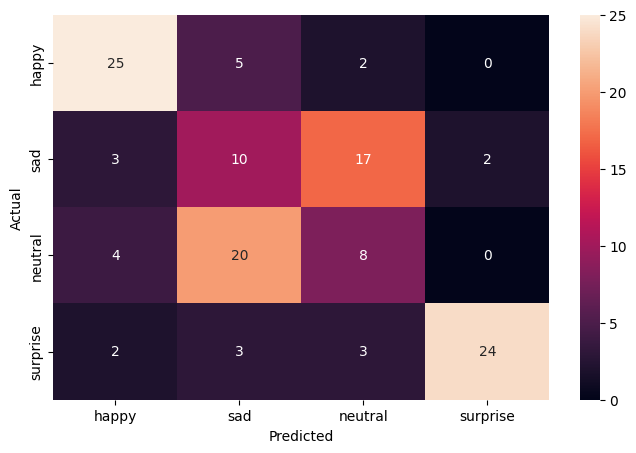

In [ ]:
# Plot the confusion matrix and generate a classification report for the model
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

test_set = datagen_test.flow_from_directory(folder_path + "test",
                                                              target_size = (img_size,img_size),
                                                              color_mode = 'grayscale',
                                                              batch_size = 128,
                                                              class_mode = 'categorical',
                                                              classes = ['happy', 'sad', 'neutral', 'surprise'],
                                                              shuffle = True)

test_images, test_labels = next(test_set)

# Write the name of your chosen model in the blank
pred = model2.predict(test_images)
pred = np.argmax(pred, axis = 1)
y_true = np.argmax(test_labels, axis = 1)

# Printing the classification report
print(classification_report(y_true, pred))

# Plotting the heatmap using confusion matrix
cm = confusion_matrix(y_true, pred)
plt.figure(figsize = (8, 5))
sns.heatmap(cm, annot = True,  fmt = '.0f', xticklabels = ['happy', 'sad', 'neutral', 'surprise'], yticklabels = ['happy', 'sad', 'neutral', 'surprise'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

**Observations and Insights:__**

## **Conclusion:____________**

### **Insights**

### **Refined insights**:
- What are the most meaningful insights from the data relevant to the problem?

### **Comparison of various techniques and their relative performance**:
- How do different techniques perform? Which one is performing relatively better? Is there scope to improve the performance further?

### **Proposal for the final solution design**:
- What model do you propose to be adopted? Why is this the best solution to adopt?